In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [148]:
df=pd.read_csv('wine.csv')
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [150]:
df.isna().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [151]:
df.duplicated().sum()

np.int64(0)

In [152]:
data=df.copy()

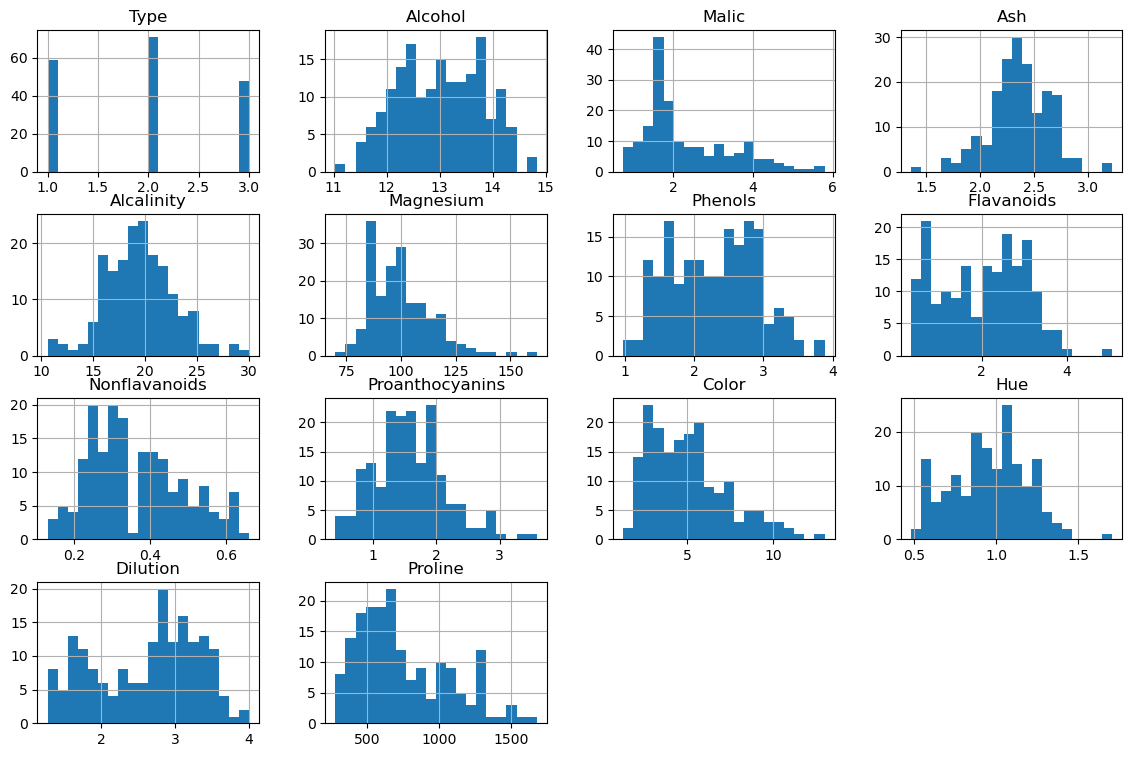

In [153]:
df.hist(figsize=(14,9), bins=20)
plt.show()

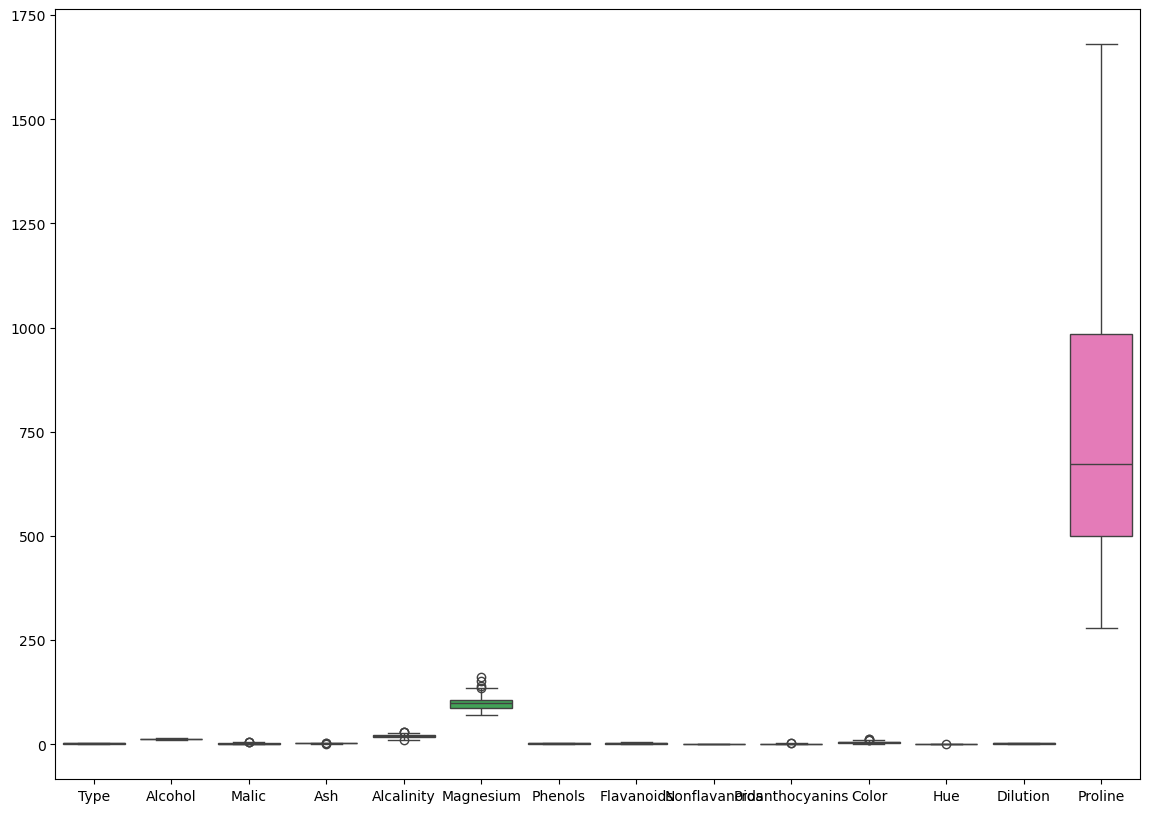

In [154]:
plt.figure(figsize=(14, 10)) 
sns.boxplot(data=df)
plt.show()


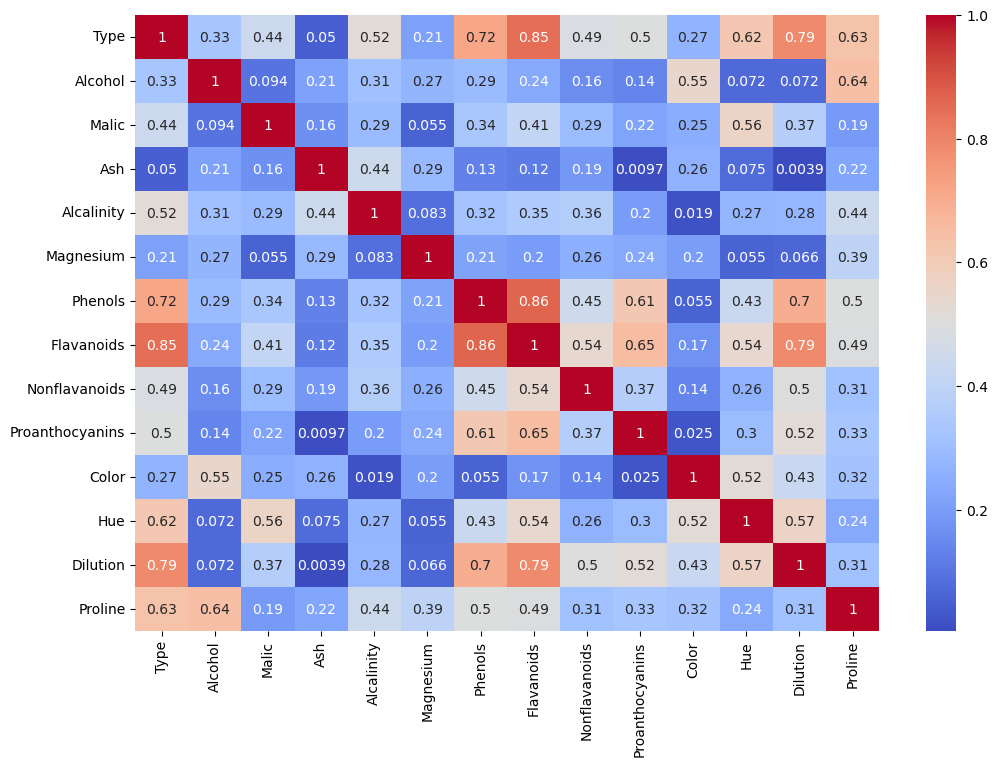

In [155]:
corr_matrix = df.corr().abs() 
plt.figure(figsize=(12, 8)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [156]:
threshold = 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features to drop
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Highly correlated features to drop:", to_drop)

# Drop those features
df_reduced = df.drop(columns=to_drop)

Highly correlated features to drop: ['Flavanoids']


## Standardized Data

In [157]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_reduced)

In [158]:
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

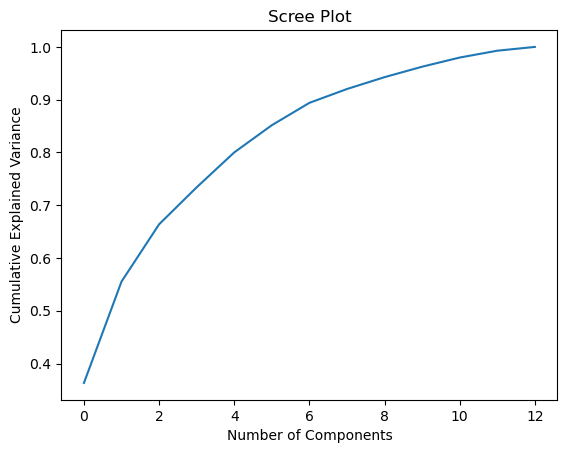

In [159]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.show()

In [160]:
pca = PCA(n_components=8)
pca_data = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'])
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-3.400406,1.450529,0.001171,0.307761,0.580618,0.271452,0.556923,-0.122855
1,-2.486926,-0.332450,-1.935083,-0.523843,-0.091136,0.916197,0.026355,-0.999977
2,-2.475078,1.036126,0.994357,0.564999,-0.671879,-0.550187,0.419840,0.120471
3,-3.628601,2.766141,-0.122386,0.452993,-0.524406,-0.299557,-0.434904,-0.713282
4,-1.203976,0.867816,2.083459,-0.241879,0.219067,0.577434,0.460484,-0.410853
...,...,...,...,...,...,...,...,...
173,3.336957,2.208502,-0.471852,0.374958,-1.205026,1.079227,0.845858,0.248044
174,2.657022,1.753647,0.160326,0.438865,-0.005433,0.038267,0.117036,0.546550
175,2.688250,2.756997,-0.979694,0.897095,0.926742,0.015574,0.760911,0.009846
176,2.390515,2.294435,-0.524782,-0.055661,1.191369,-0.975531,0.765246,-0.445076


## KMeans for Original Data

In [161]:
kmeans_original = KMeans(n_clusters=4, random_state=42)
clusters_original = kmeans_original.fit_predict(scaled_data)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [162]:
kmeans_original.inertia_

1147.2174939244567

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

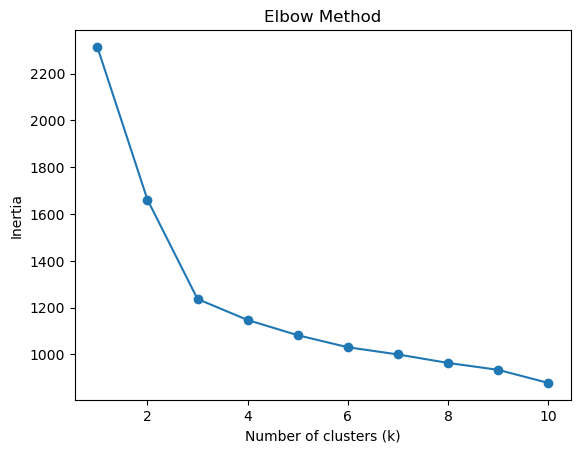

In [163]:
inertia = []

# Try different values of k
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

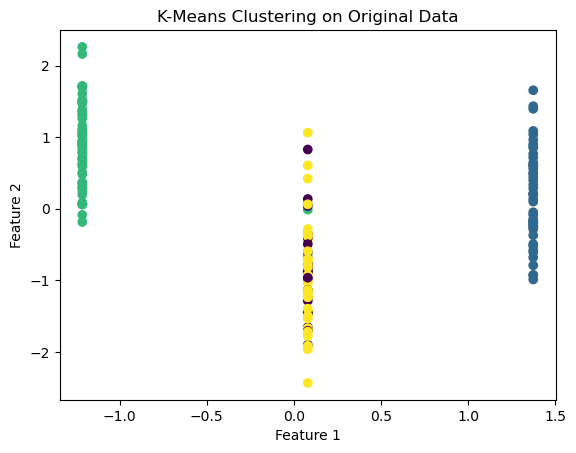

In [164]:
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=clusters_original, cmap='viridis')
plt.title("K-Means Clustering on Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [165]:
# Evaluate with silhouette score
sil_original = silhouette_score(scaled_data, clusters_original)
print("Silhouette Score (Original Data):", sil_original)

Silhouette Score (Original Data): 0.2564480944550069


## KMeans for PCA Data

In [166]:
kmeans_pca = KMeans(n_clusters=4, random_state=42)
clusters_pca = kmeans_pca.fit_predict(pca_df)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [167]:
kmeans_pca.inertia_

966.7834734092025

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

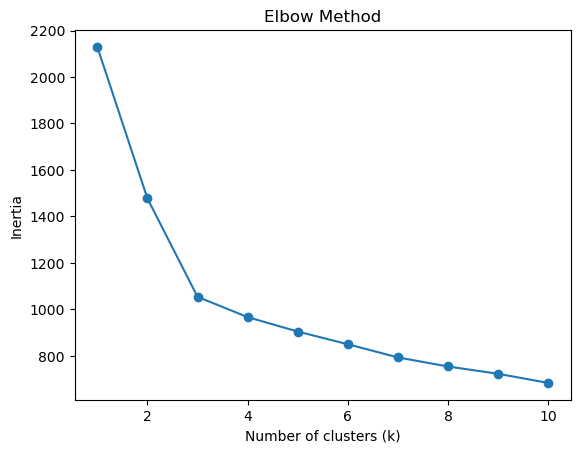

In [168]:
inertia = []

# Try different values of k
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_df)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

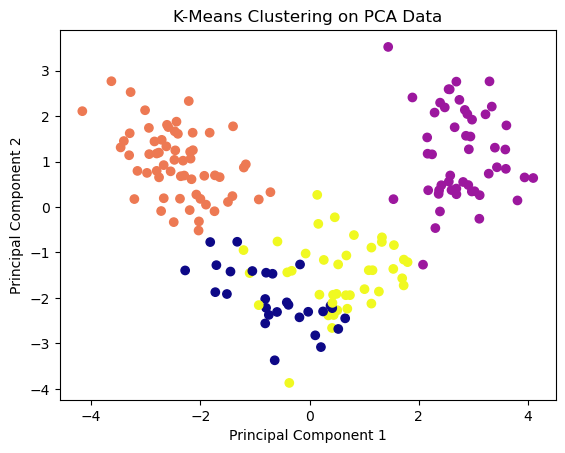

In [169]:
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=clusters_pca, cmap='plasma')
plt.title("K-Means Clustering on PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [170]:
sil_pca = silhouette_score(pca_df, clusters_pca)
print("Silhouette Score (PCA Data):", sil_pca)

Silhouette Score (PCA Data): 0.2804911095647057


#### Comparison and Analysis

###### After removing highly correlated features, the clustering results showed that the PCA-transformed data achieved a slightly higher Silhouette Score (0.280) compared to the original data (0.256). This indicates that PCA improved the separation and compactness of clusters by reducing redundancy and noise among features. While both approaches produced similar cluster patterns, PCA-based clustering resulted in slightly clearer boundaries and more efficient computation. However, this improvement comes with reduced interpretability, as PCA components do not directly represent the original features. Overall, dimensionality reduction through PCA enhanced clustering performance modestly while simplifying the data structure.

#### Conclusion and Insights

###### In conclusion, the analysis showed that applying PCA and removing highly correlated features helped improve clustering performance slightly, as seen from the higher silhouette score. PCA effectively reduced data redundancy, improved computational efficiency, and enhanced cluster separation. In practical terms, using PCA is beneficial when dealing with high-dimensional or correlated data, as it simplifies the dataset while retaining most of the important information. However, clustering on the original data is preferable when feature interpretability is crucial. Overall, PCA should be used when the goal is to improve model performance and efficiency, while the original data is better for understanding specific feature-level insights.